In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader,Dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
original_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [24]:
# Load original datasets
train_dataset = datasets.ImageFolder("/home/deep/Documents/ISIC2016 original/train/", transform=original_transform)
test_dataset = datasets.ImageFolder("//home/deep/Documents/ISIC2016 original/test/", transform=original_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [28]:
model_ViT = models.vit_b_16(pretrained=True)

In [29]:
num_classes = 2
model_ViT.heads = nn.Linear(768, num_classes)

In [30]:
import torch.nn as nn

# Freeze the parameters in the Vision Transformer model
for parameter in model_ViT.parameters():
    parameter.requires_grad = False

# Assuming the ViT model's classification head is named 'heads'
num_features = 768

# Replace the classification head with a custom sequence of layers
model_ViT.heads = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 2)
)

# Move the model to the device (GPU or CPU)
model_ViT.to(device)


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [34]:
from torchinfo import summary

summary(model=model_ViT,
        input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [32, 3, 224, 224]    [32, 2]              768                  Partial
├─Conv2d (conv_proj)                                         [32, 3, 224, 224]    [32, 768, 14, 14]    (590,592)            False
├─Encoder (encoder)                                          [32, 197, 768]       [32, 197, 768]       151,296              False
│    └─Dropout (dropout)                                     [32, 197, 768]       [32, 197, 768]       --                   --
│    └─Sequential (layers)                                   [32, 197, 768]       [32, 197, 768]       --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [32, 197, 768]       [32, 197, 768]       (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [32, 197, 768]       [32, 

In [36]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np

def train_model(model_ViT, train_loader, criterion, optimizer, num_epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_ViT.to(device)

    for epoch in range(num_epochs):
        model_ViT.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # Wrap the train_loader with tqdm for a progress bar
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model_ViT(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Update the progress bar description
            progress_bar.set_description(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/total:.4f}, Acc: {100*correct/total:.2f}%')

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

    print('Finished Training')


In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model_ViT, test_loader, device):
    model_ViT.eval()
    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_ViT(inputs)
            _, predicted = torch.max(outputs, 1)
            true_labels.extend(labels.cpu().numpy())
            predicted_labels.extend(predicted.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average='weighted')
    recall = recall_score(true_labels, predicted_labels, average='weighted')
    f1 = f1_score(true_labels, predicted_labels, average='weighted')

    # Calculate confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    return accuracy, precision, recall, f1, cm

def plot_confusion_matrix(cm, title='Confusion Matrix'):
    # plt.figure(figsize=(8, 6))
    # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    # plt.title(title)
    # plt.xlabel('Predicted Label')
    # plt.ylabel('True Label')
    # plt.show()
    group_names = ['True Positive (TP)', 'False Negative (FN)',
               'False Positive (FP)', 'True Negative (TN)']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()


Epoch 1/20, Loss: 0.0158, Acc: 80.31%: 100%|████| 29/29 [00:41<00:00,  1.44s/it]


Epoch 1/20, Loss: 0.4898, Accuracy: 80.31%


Epoch 2/20, Loss: 0.0134, Acc: 81.20%: 100%|████| 29/29 [00:39<00:00,  1.37s/it]


Epoch 2/20, Loss: 0.4159, Accuracy: 81.20%


Epoch 3/20, Loss: 0.0124, Acc: 81.65%: 100%|████| 29/29 [00:40<00:00,  1.41s/it]


...

Epoch 18/20, Loss: 0.2307, Accuracy: 90.43%


Epoch 19/20, Loss: 0.0074, Acc: 91.55%: 100%|███| 29/29 [00:45<00:00,  1.56s/it]


Epoch 19/20, Loss: 0.2296, Accuracy: 91.55%


Epoch 20/20, Loss: 0.0071, Acc: 92.10%: 100%|███| 29/29 [00:45<00:00,  1.56s/it]


Epoch 20/20, Loss: 0.2200, Accuracy: 92.10%
Finished Training
model_ViT - Accuracy: 0.8259, Precision: 0.8065, Recall: 0.8259, F1 Score: 0.8097


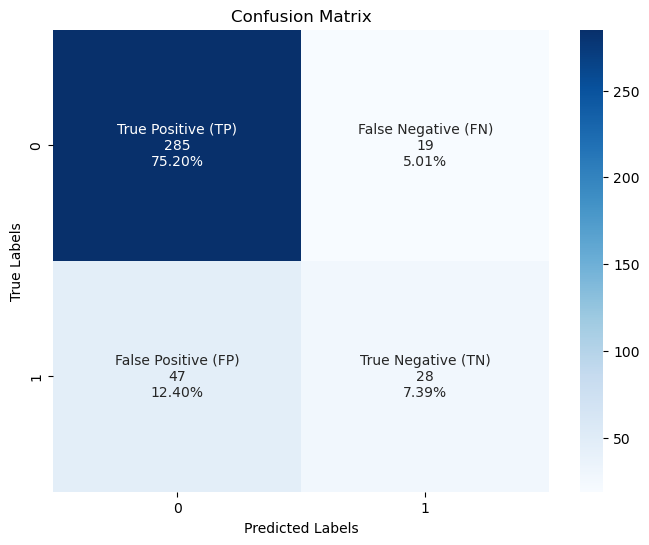

In [40]:
# Example for model_ViT
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_ViT.parameters(), lr=0.0001)

train_model(model_ViT, train_loader, criterion, optimizer, num_epochs=20)


import numpy as np
# Example for model_ViT
accuracy, precision, recall, f1, cm = evaluate_model(model_ViT, test_loader, device)
print(f'model_ViT - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')
plot_confusion_matrix(cm, 'Confusion Matrix for model_ViT')